In [1]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import struct
import matplotlib.pyplot as plt

In [2]:
gt_input_file = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/groundtruth_1000.tsv"
columns = ["query_id", "doc_id", "rank", "score"]
gt = pd.read_csv(gt_input_file, sep="\t", names=columns)

In [3]:
real_gt_input_file = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/groundtruth.tsv"
columns = ["query_id", "doc_id", "rank", "score"]
real_gt = pd.read_csv(real_gt_input_file, sep="\t", names=columns)

In [4]:
def read_sparse_vectors_from_binary_file(filename):
    term_id = []
    with open(filename, "rb") as f:
        # Read the number of term vectors (sparse vectors)
        num_vectors = int.from_bytes(f.read(4), byteorder='little', signed=False)
        for _ in tqdm(range(num_vectors)):
            # Read the length of the integer sequence
            seq_len = int.from_bytes(f.read(4), byteorder='little', signed=False)
            
            # Read the integer sequence (indices)
            int_seq = np.array([int.from_bytes(f.read(4), byteorder='little', signed=False) for _ in range(seq_len)], dtype=np.int32)
            
            # Read the float sequence (values)
            float_seq = np.array([struct.unpack('f', f.read(4))[0] for _ in range(seq_len)], dtype=np.float32)
            
            # Append the parsed term (as two lists: indices and values) to term_id
            term_id.append((int_seq, float_seq))
    
    return term_id

In [5]:
queries_file = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/queries.bin"
queries = read_sparse_vectors_from_binary_file(queries_file)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6980/6980 [00:00<00:00, 45233.13it/s]


In [ ]:
document_file = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/documents.bin"
documents = read_sparse_vectors_from_binary_file(document_file)

 50%|██████████████████████████████████████████████████████████████████████████████████▏                                                                                | 4456025/8841823 [04:10<04:06, 17824.29it/s]

In [ ]:
import json
quantization_bins_path = "/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_quantization_bins.json"
with open(quantization_bins_path) as f:
    quantiztion_value = json.load(f)
converted_quantization_value = {int(k): (v["min"], v["max"], v["scale"], v["mean"]) for k,v in quantiztion_value.items()}

In [129]:
enriched_quantization_values = {}
for k, v in tqdm(converted_quantization_value.items()):
    current_values = all_components.get_component_values(k)
    p_99 = np.percentile(current_values, 99)
    p_5 = np.percentile(current_values, 5)
    v_ = {}

  0%|                                                                                                                                                                                      | 0/28679 [00:00<?, ?it/s]


AttributeError: 'tuple' object has no attribute 'items'

#### analysis

In [ ]:
#quantization_bins_path_queries = "/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_queries_quantization_bins.json"
# with open(quantization_bins_path_queries) as f:
#     inverted_index_queries = json.load(f)
#converted_inverted_index_queries = {int(k): (v["min"], v["max"], v["scale"], v["mean"]) for k,v in inverted_index_queries.items()}

In [62]:
class ComponentValuesReader:

    def __init__(self, counts_file="/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_counts.npy", values_file="/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_values.npy"):
        self.component_counts = np.load(counts_file)
        self.all_values = np.load(values_file)
        
        # Pre-calcola tutti gli offset per accesso O(1)
        self.offsets = np.cumsum(np.concatenate([[0], self.component_counts[:-1]]))
        
    def get_component_values(self, component_index):

        start = self.offsets[component_index]
        end = start + self.component_counts[component_index]
        return self.all_values[start:end]
    
    def get_component_count(self, component_index):

        return self.component_counts[component_index]
    
    def get_num_components(self):

        return len(self.component_counts)

In [63]:
all_components = ComponentValuesReader()
all_components_queries = ComponentValuesReader(counts_file="/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_queries_counts.npy", values_file="/home/cosimorulli/rgb_in_seismic/seismic_private/inverted_index_queries_values.npy")

In [ ]:
value = 2.0
np.sum(np.sort(c_values) <= value)

In [ ]:
def evaluate_function(c_values, split_point, bits_first_half, bits_second_half):
    c_values = np.sort(c_values)
    x = np.sum(np.sort(c_values) <= split_point)
    cost = 0
    
    bin_size_first_part = (split_point - c_values[0]) / bits_first_half
    for c_val in c_values[:x]:
        quantization_bin = int((c_val - c_values[0]) / bin_size_first_part)
        quantization_value = c_values[0] + quantization_bin * bin_size_first_part
        cost += np.abs(c_val - quantization_value) * c_val

    bin_size_second_part = (c_values[-1] - split_point) / bits_second_half
    for c_val in c_values[x:]:
        quantization_bin = int((c_val - split_point) / bin_size_second_part)
        quantization_value = split_point + quantization_bin * bin_size_second_part
        cost += np.abs(c_val - quantization_value) * c_val
    return cost

In [ ]:
def exhaustive_search(c_values, bits_first_half, bits_second_half):
    costs = {}
    for split_point in np.arange(0.0, round(np.max(c_values), 1) + 0.1, 0.1):
        costs[split_point] = evaluate_function(c_values, split_point, bits_first_half, bits_second_half)
    return costs

In [ ]:
import operator
split = min(costs.items(), key=operator.itemgetter(1))[0]

In [ ]:
bits_first_half = 64
bits_second_half = 192
splits_per_component = {}

for component_id in tqdm(range(all_components.get_num_components())):
    values = all_components.get_component_values(component_id)
    costs = exhaustive_search(values, bits_first_half, bits_second_half)
    splits_per_component[component_id] = min(costs.items(), key=operator.itemgetter(1))[0]

(array([5.5330e+04, 2.3271e+04, 1.2578e+04, 1.0811e+04, 9.9750e+03,
        6.1510e+03, 1.8500e+03, 4.8900e+02, 1.2400e+02, 2.1000e+01]),
 array([9.76085954e-04, 2.23930314e-01, 4.46884543e-01, 6.69838786e-01,
        8.92793000e-01, 1.11574721e+00, 1.33870149e+00, 1.56165564e+00,
        1.78460991e+00, 2.00756407e+00, 2.23051834e+00]),
 <BarContainer object of 10 artists>)

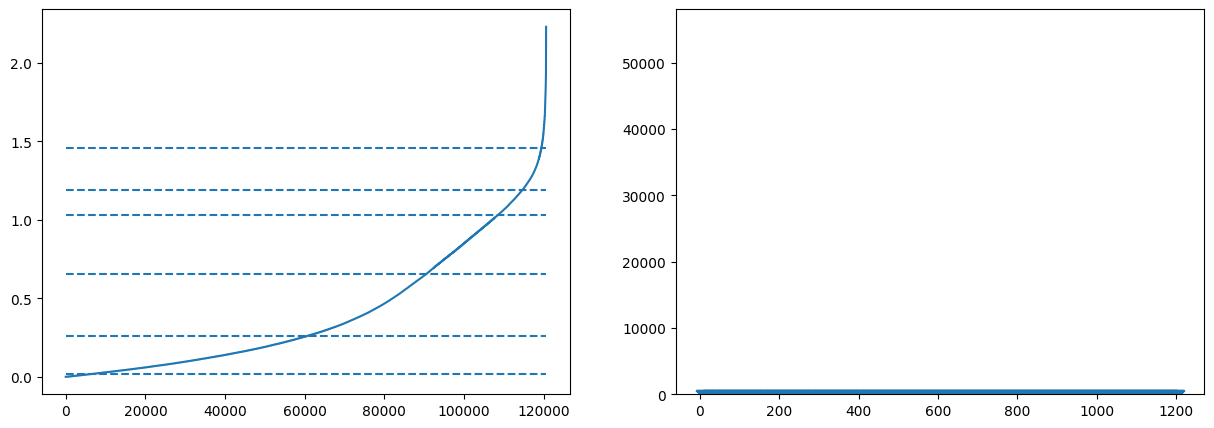

In [163]:
id = 20000
fig, axs = plt.subplots(figsize= (15, 5), ncols=2)
c_values = all_components.get_component_values(id)
#axs[0].hlines(y=(np.max(c_values) - np.min(c_values)) / 2, xmin=0, xmax=len(c_values))
#axs[0].hlines(y=np.mean(c_values), xmin=0, xmax=len(c_values), linestyle ="--")

for percentile in [5, 50, 75, 90, 95, 99]:
    axs[0].hlines(y=np.percentile(c_values, percentile), xmin=0, xmax=len(c_values), linestyle ="--")
    



#axs[0].hlines(y=0.5, xmin=0, xmax=len(c_values))

c_values_queries = all_components_queries.get_component_values(id)
axs[0].plot(np.sort(c_values))
mask = c_values >= np.percentile(c_values, 99)
plt.scatter(np.arange(np.sum(mask)), c_values[mask], marker="x")
axs[1].hist(c_values)
#axs[1].plot(np.sort(c_values_queries))
# plt.show()
# plt.hist(c_values)
# plt.hist(c_values_queries)




### Try some spline based stuff

In [95]:
import numpy as np
from scipy.interpolate import LSQUnivariateSpline, UnivariateSpline

def approximate_with_spline(values, n_knots=1):
    values = np.array(values)
    n = len(values)
    x = np.arange(n)
    
    if n_knots == 1:
        knot_position = n // 2
        knots = np.array([knot_position])
    else:
        knots = np.linspace(x[1], x[-2], n_knots)
    
    spline = LSQUnivariateSpline(x, values, knots, k=1)
    
    y_approx = spline(x)
    mse = np.mean((values - y_approx)**2)
    
    return {
        'spline': spline,
        'knots': knots,
        'y_approx': y_approx,
        'error': mse
    }


def find_optimal_knot(values):
    values = np.array(values)
    n = len(values)
    x = np.arange(n)
    
    best_error = np.inf
    best_knot = None
    best_spline = None
    
    for knot_pos in range(2, n-2):
        try:
            spline = LSQUnivariateSpline(x, values, [knot_pos], k=1)
            y_pred = spline(x)
            error = np.sum((values - y_pred)**2)
            
            if error < best_error:
                best_error = error
                best_knot = knot_pos
                best_spline = spline
        except:
            continue
    
    y_approx = best_spline(x)
    mse = np.mean((values - y_approx)**2)
    
    return {
        'spline': best_spline,
        'knot': best_knot,
        'y_approx': y_approx,
        'error': mse
    }


import numpy as np
from scipy.optimize import minimize_scalar

import numpy as np
from scipy.optimize import minimize_scalar

def approximate_with_two_lines_constrained(values, fixed_point_idx, fixed_point_value):
    values = np.array(values)
    n = len(values)
    x = np.arange(n)
    
    def calculate_error(idx_break):
        idx_break = int(idx_break)
        
        if idx_break < 2 or idx_break >= n - 2:
            return np.inf
        
        if fixed_point_idx < idx_break:
            return np.inf
        
        x1 = x[:idx_break+1]
        y1 = values[:idx_break+1]
        m1, q1 = np.polyfit(x1, y1, 1)
        
        x2 = x[idx_break:]
        y2 = values[idx_break:]
        
        mask = x2 != fixed_point_idx
        x2_fit = x2[mask]
        y2_fit = y2[mask]
        
        sum_x = np.sum(x2_fit)
        sum_y = np.sum(y2_fit)
        sum_xy = np.sum(x2_fit * y2_fit)
        sum_x2 = np.sum(x2_fit * x2_fit)
        n_other = len(x2_fit)
        
        m2 = ((n_other * fixed_point_value - sum_y) * fixed_point_idx - (n_other * fixed_point_idx - sum_x) * fixed_point_value + sum_xy - sum_x * sum_y / n_other) / (fixed_point_idx**2 * n_other - 2 * fixed_point_idx * sum_x + sum_x2)
        q2 = fixed_point_value - m2 * fixed_point_idx
        
        y_pred1 = m1 * x1 + q1
        y_pred2 = m2 * x2 + q2
        
        error = np.sum((y1 - y_pred1)**2) + np.sum((y2 - y_pred2)**2)
        return error
    
    result = minimize_scalar(calculate_error, bounds=(2, n-2), method='bounded')
    idx_break = int(result.x)
    
    x1 = x[:idx_break+1]
    y1 = values[:idx_break+1]
    m1, q1 = np.polyfit(x1, y1, 1)
    
    x2 = x[idx_break:]
    y2 = values[idx_break:]
    
    mask = x2 != fixed_point_idx
    x2_fit = x2[mask]
    y2_fit = y2[mask]
    
    sum_x = np.sum(x2_fit)
    sum_y = np.sum(y2_fit)
    sum_xy = np.sum(x2_fit * y2_fit)
    sum_x2 = np.sum(x2_fit * x2_fit)
    n_other = len(x2_fit)
    
    m2 = ((n_other * fixed_point_value - sum_y) * fixed_point_idx - (n_other * fixed_point_idx - sum_x) * fixed_point_value + sum_xy - sum_x * sum_y / n_other) / (fixed_point_idx**2 * n_other - 2 * fixed_point_idx * sum_x + sum_x2)
    q2 = fixed_point_value - m2 * fixed_point_idx
    
    y_approx = np.concatenate([
        m1 * x1 + q1,
        (m2 * x2 + q2)[1:]
    ])
    
    mse = np.mean((values - y_approx)**2)
    
    verification = m2 * fixed_point_idx + q2
    
    return {
        'breakpoint': idx_break,
        'line1': (m1, q1),
        'line2': (m2, q2),
        'y_approx': y_approx,
        'error': mse,
        'verification': verification
    }


In [96]:
sorted_c_values = np.sort(c_values)
result = approximate_with_two_lines_constrained(sorted_c_values, len(sorted_c_values) -1, sorted_c_values[-1])


2.942793

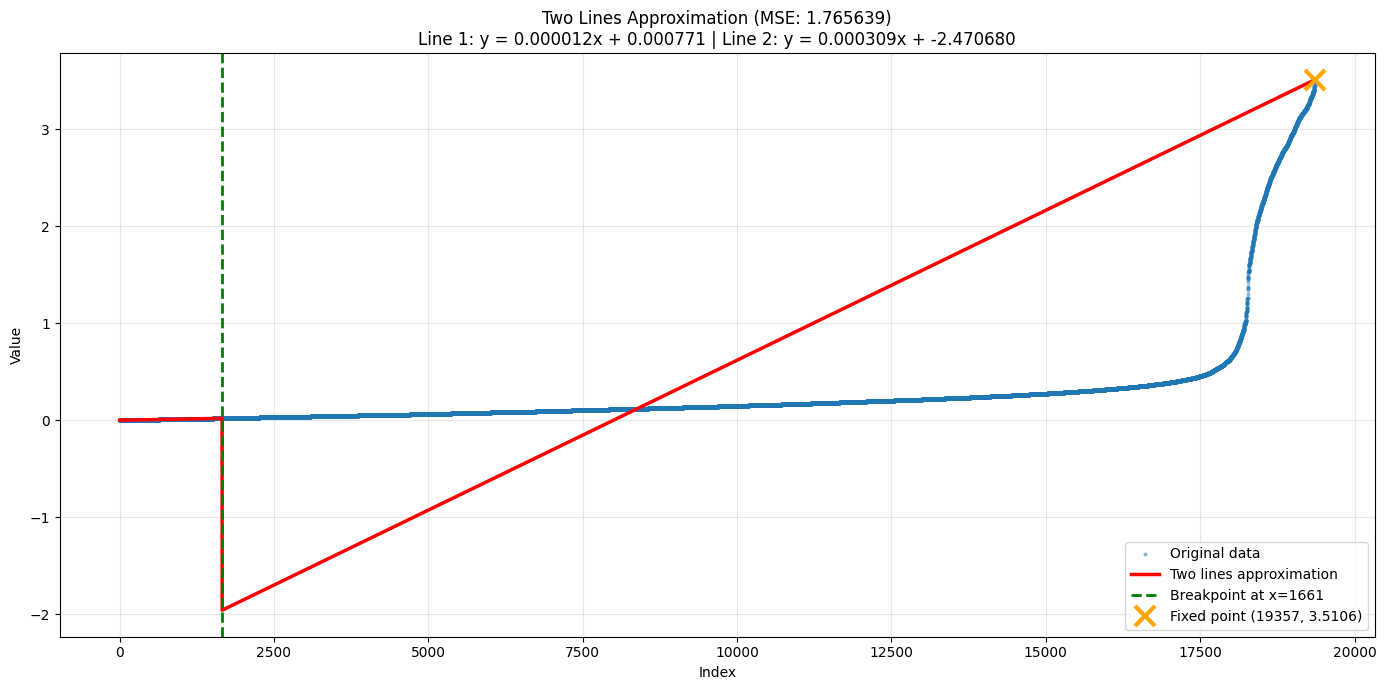

In [97]:
import matplotlib.pyplot as plt
import numpy as np

def plot_two_lines_result(values, result, fixed_point_idx=None, fixed_point_value=None):
    x = np.arange(len(values))
    
    plt.figure(figsize=(14, 7))
    plt.plot(x, values, 'o', label='Original data', alpha=0.4, markersize=2)
    plt.plot(x, result['y_approx'], '-', linewidth=2.5, label='Two lines approximation', color='red')
    plt.axvline(result['breakpoint'], color='green', linestyle='--', linewidth=2, label=f'Breakpoint at x={result["breakpoint"]}')
    
    if fixed_point_idx is not None and fixed_point_value is not None:
        plt.plot(fixed_point_idx, fixed_point_value, 'x', markersize=15, markeredgewidth=3, 
                color='orange', label=f'Fixed point ({fixed_point_idx}, {fixed_point_value:.4f})')
    
    m1, q1 = result['line1']
    m2, q2 = result['line2']
    
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title(f'Two Lines Approximation (MSE: {result["error"]:.6f})\n' + 
              f'Line 1: y = {m1:.6f}x + {q1:.6f} | Line 2: y = {m2:.6f}x + {q2:.6f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_two_lines_result(sorted_c_values, result, fixed_point_idx=len(sorted_c_values) - 1, fixed_point_value=sorted_c_values[-1])

# Evaluation

In [9]:
grouped_gt = gt.groupby("query_id")

In [ ]:
#quantizer = ExponentialQuantization([], quantization_info=converted_quantization_value)


In [161]:
class UnbalancedUniformQuantization():
    def __init__(self, quantization_info, nbits=8, pivoting_strategy="mean", first_num_bins=64):
        self.quantization_info = {}
        self.nbits = nbits

        self.first_num_bins = first_num_bins  
        self.hit_above = 0
        self.hit_below = 0

        second_num_bins = 2**nbits - self.first_num_bins
        for k, v in quantization_info.items():
            min_val, max_val, _, mean_val = v
            if pivoting_strategy == "mean":
                pivot = mean_val
            elif pivoting_strategy == "midpoint":
                pivot = (min_val + max_val) / 2.0
            elif pivoting_strategy == "0.8":
                pivot = max_val * 0.8
            elif pivoting_strategy == "0.8":
                pivot = max_val * 0.5
            else:
                pivot = mean_val
                
            
            first_bin_size = (pivot - min_val) / self.first_num_bins
            second_bin_size = (max_val - pivot) / second_num_bins
            
            self.quantization_info[k] = (min_val, max_val, first_bin_size, second_bin_size, pivot)

    def compute_dot_product(self, query, hashed_doc):
        query_dict = dict(zip(*query))
        doc_dict = dict(zip(*hashed_doc))
        score = 0
        for k, v in query_dict.items():
            if k in doc_dict:
                score += self.quantize_value(k, doc_dict[k]) * v
        return score

    def quantize_value(self, component, value):
        min_val, max_val, first_bin_size, second_bin_size, pivot = self.quantization_info[component]
        

        if value <= pivot:
            self.hit_below += 1

            quantization_bin = self.first_num_bins - int(round((pivot - value) / first_bin_size))
            quantization_bin = max(0, min(self.first_num_bins, quantization_bin))
        else:

            self.hit_above += 1

            quantization_bin = self.first_num_bins + int(round((value - pivot) / second_bin_size))
            quantization_bin = max(self.first_num_bins, min(255, quantization_bin))
        
        if quantization_bin <= self.first_num_bins:
            quantization_value = pivot - first_bin_size * (self.first_num_bins - quantization_bin)
        else:
            quantization_value = pivot + second_bin_size * (quantization_bin - self.first_num_bins)
            
        return quantization_value

In [147]:
MODES = ["gt", "st", "0.1", "0.2", "0.5", None]

class UniformQuantization():

    def __init__(self, quantization_info, nbits=8, components=None, mode=None):
        self.quantization_info = {}
        self.nbits = nbits
        self.components = components
        
        for k, v in tqdm(quantization_info.items()):
            min_val, max_val, _, mean_val = v
            

            if components is not None:
                values = components.get_component_values(k)
                p_5 = np.percentile(values, 5)
                p_99 = np.percentile(values, 99)
                

                span = (p_99 - p_5)
                num_bins = 2**nbits - 1
                bin_size = span / num_bins if num_bins > 0 else 0
                

                self.quantization_info[k] = (p_5, p_99, bin_size, mean_val, p_5, p_99)
            else:
                # Fallback ai valori originali se non abbiamo accesso ai componenti
                span = (max_val - min_val)
                num_bins = 2**nbits - 1
                bin_size = span / num_bins if num_bins > 0 else 0
                self.quantization_info[k] = (min_val, max_val, bin_size, mean_val, min_val, max_val)
                
        assert mode in MODES
        self.mode = mode 
        
    def compute_dot_product(self, query, hashed_doc):
        query_dict = dict(zip(*query))
        doc_dict = dict(zip(*hashed_doc))
        score = 0
        for k, v in query_dict.items():
            if k in doc_dict:
                score += self.quantize_value(k, doc_dict[k]) * v
        return score

    def quantize_value(self, component, value):
        min_val, max_val, bin_size, mean_val, p_5, p_99 = self.quantization_info[component]

        # # Modalità opzionali
        # if self.mode == "gt" and value >= mean_val:
        #     return value
        
        # if self.mode == "st" and value <= mean_val:
        #     return value

        # if self.mode == "0.1" and value >= max_val * 0.9:
        #     return value

        # if self.mode == "0.2" and value >= max_val * 0.8:
        #     return value

        # if self.mode == "0.5" and value >= max_val * 0.5:
        #     return value
            
        # Clamp il valore nel range dei percentili
        if value > p_99:
            return value
        value = max(p_5, min(p_99, value))
        
        if bin_size == 0:
            return p_5
            
        # Quantizza usando il range dei percentili
        quantization_bin = int((value - p_5) / bin_size)        
        quantization_bin = max(0, min(2**self.nbits - 1, quantization_bin))
        quantization_value = p_5 + quantization_bin * bin_size
        return quantization_value

In [ ]:
#quantizer = UniformQuantization(converted_quantization_value, mode="st", components=all_components, nbits=6)
#quantizer = UniformQuantization(converted_quantization_value, mode="st", nbits=8)

quantizer = UnbalancedUniformQuantization(converted_quantization_value, pivoting_strategy="mean", first_num_bins=32, nbits=8)
results = []
k = 10
stop_at = 1000
for (i, query) in tqdm(enumerate(queries[:stop_at])):
    candidates = grouped_gt.get_group(i).doc_id.values

    query_indices = [i] * len(candidates)
    scores = np.zeros(len(candidates))

    
    for (j, doc_id) in enumerate(candidates):
        dot = quantizer.compute_dot_product(query, documents[doc_id]) 
        scores[j] = dot

        
    df = pd.DataFrame({"query_id": query_indices, "score": scores, "doc_id": candidates})
    df = df.sort_values("score", ascending=False)[:k]
    results.append(df)

results = pd.concat(results)

988it [02:47,  5.58it/s]

In [ ]:
# print(f"Hit below pivot: {quantizer.hit_below}")
# print(f"Hit above pivot: {quantizer.hit_above}")
# print(f"Total hits: {quantizer.hit_below + quantizer.hit_above}")

In [ ]:
selected_groundtruth = real_gt[:len(results)]
compute_accuracy(selected_groundtruth, results)


**8 bits**

- "base", 1000 queries = 99.28
- "st", 1000 queries = 99.26
- "gt", 1000 queries = 99.62
- "0.1",1000 queries = 99.31
- "0.2",1000 queries = 99.32
- "0.5",1000 queries = 99.39

**6 bits**

- "base", 1000 queries =  97.01
- "st", 1000 queries = 97.06
- "gt", 1000 queries = 98.84
- "0.1",1000 queries = 97.02
- "0.2",1000 queries = 
- "0.5",1000 queries = 

In [11]:
def compute_accuracy(gt_pd, res_pd):
    gt_pd_groups = gt_pd.groupby('query_id')['doc_id'].apply(set)
    res_pd_groups = res_pd.groupby('query_id')['doc_id'].apply(set)

    # Compute the intersection size for each query_id in both dataframes
    intersections_size = {
        query_id: len(gt_pd_groups[query_id] & res_pd_groups[query_id]) if query_id in res_pd_groups else 0
        for query_id in gt_pd_groups.index
    }

    # Computes total number of results in the groundtruth
    total_results = len(gt_pd)
    total_intersections = sum(intersections_size.values())
    return total_intersections/total_results

### Plots for exp quantization

In [ ]:
query0 = gt.groupby("query_id").get_group(0)

In [ ]:
dist = np.random.uniform(0, 5, 20000)

In [ ]:
nbits = 8
min_ = np.min(dist)
max_ = np.max(dist)
scale = np.power(np.max(dist) / np.min(dist), 1/2**nbits)

In [ ]:
bins = []
for value in dist: 
    quantization_bin = np.floor(np.log(value / min_) / np.log(scale)) 
    bins.append(max_ - scale**quantization_bin * min_)

In [ ]:
bins = np.unique(bins)
plt.scatter(np.arange(len(bins)), bins)

In [ ]:
plt.scatter(np.arange(len(dist)), np.sort(dist))